# makemore - Bigram Character-Level Language Model

Building a character-level name generator in two stages:
1. A **bigram** model built from raw counts (a lookup table of P(next char | current char)).
2. The same model re-derived as a **single-layer neural network**, trained by gradient descent, to set up the transition to deeper models.

Dataset: `names.txt`, one name per line.

In [52]:
# Load the raw dataset: one name per line, which becomes the entire corpus every count, probability, and later the neural net is derived from.

words = open('names.txt','r').read().splitlines()

In [53]:
# Peek at the first 10 names to sanity-check the data loaded correctly, before trusting it for anything downstream.

words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [54]:
# Check how many names we have, since that determines how many bigram examples the model gets to learn from.

len(words)

32033

In [55]:
# Find the shortest name, just to get a feel for the range of word lengths being modeled.

min(len(w) for w in words)

2

In [56]:
# Find the longest name, for the same reason -- context for how much padding/sentinel handling matters.

max(len(w) for w in words)

15

## 1. Counting Bigrams

### 1a. First pass — plain Python dictionary
Count every adjacent character pair `(ch1, ch2)`, padding each word with `<S>`/`<E>` sentinels.

In [57]:
# First pass at counting character-pair frequencies with a plain Python dict, as a quick dependency-free way to test the idea before committing to a tensor.
# <S>/<E> sentinels mark word boundaries so we also capture what tends to start and end a name.

# bigram 2 chars at a time
# given <S>, how probable is e?
b={}
for w in words:
    # pad word with starting with ending char
    chs = ['<S>'] + list(w) + ['<E>']
    # 2 pointers for the first and second char of padded word
    for ch1, ch2 in zip (chs,chs[1:]):
        #print(chs,chs[1:])
        bigram=ch1,ch2
        b[bigram]=b.get(bigram,0)+1
        #print(ch1,ch2)

In [58]:
# Rank bigrams by frequency as a sanity check that the dict-counting logic actually worked -- exploratory only, not used later.

# top 10 most comment predicitons

sorted(b.items(),key = lambda kv:-kv[1])[:10]


[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

### 1b. Tensor-based counts

Re-implemented with a `torch` count matrix `N` so we can vectorize everything downstream. `stoi`/`itos` map characters to/from integer indices `0..26`, with `.` doubling as both start and end token.

In [59]:
# Bring in PyTorch, since counts are about to move from a Python dict into a tensor that the rest of the model (indexing, broadcasting, matmuls) depends on.

import torch

In [60]:
# Allocate a 27x27 count matrix (26 letters + '.' as the start/end token) -- a placeholder that gets properly filled in and overwritten a few cells down.

N = torch.zeros((27,27),dtype=torch.int32)

In [61]:
# Build the character vocabulary and the two lookup tables (char<->index) that every later cell depends on. '.' is manually pinned to index 0 so it can double as both start and end token.

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
# track start/end delim on 26/27
stoi['.']=0
itos = {i:s for s,i in stoi.items()}

In [62]:
# Inspect the index->character mapping to confirm it looks right before trusting it for decoding.

itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [63]:
# Inspect the character->index mapping to confirm it looks right before trusting it for encoding.

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [64]:
# Repeat the bigram count, now writing directly into tensor N via stoi indices instead of a dict, so counts can be visualized and normalized with tensor ops.

# bigram 2 chars at a time
# given <S>, how probable is e?
N = torch.zeros((27,27),dtype=torch.int32)
for w in words:
    # pad word with starting with ending char
    chs = ['.'] + list(w) + ['.']
    # 2 pointers for the first and second char of padded word
    #print(chs)
    for ch1, ch2 in zip (chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        #print("appending ",ch1,ch2)
        N[ix1,ix2]+=1

In [65]:
# Confirm what type() a single count value resolves to via .item(), just to understand what comes out of an int32 tensor.

type(N[3,3].item())

int

## 2. Visualizing the Bigram Counts

Heatmap of `N`: rows = current character, columns = next character.

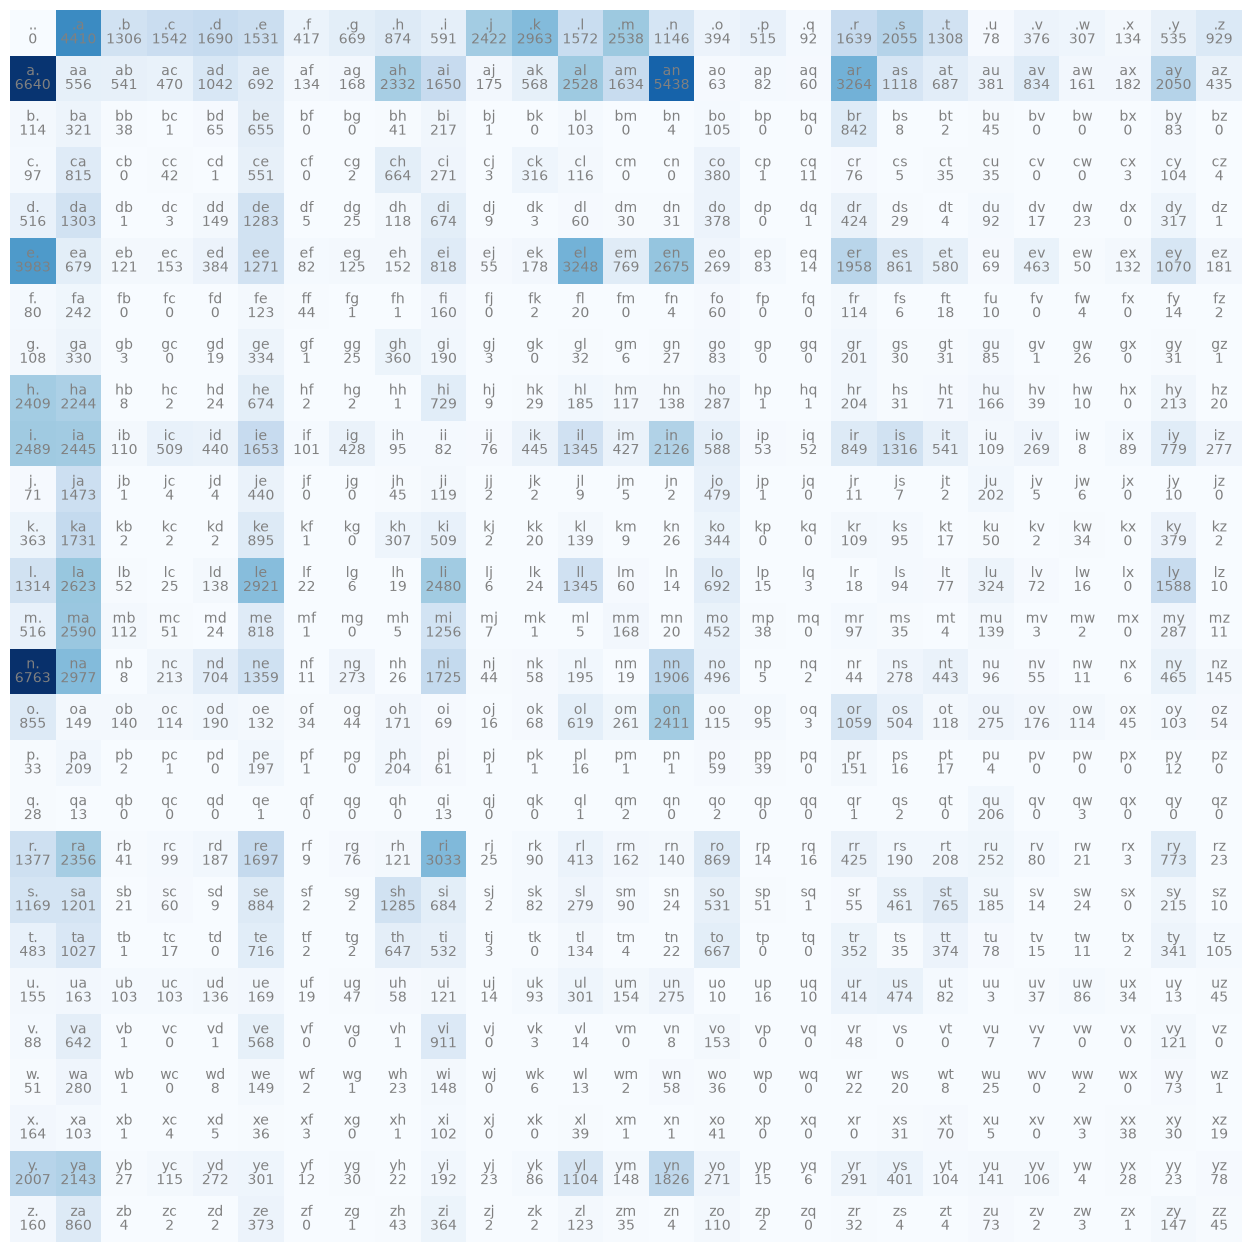

In [66]:
# Visualize the full 27x27 count matrix as a heatmap with each bigram and its count overlaid, to build intuition for which letter transitions are common or rare before turning counts into probabilities.

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

## 3. Sampling from a Distribution — Warm-up

Before sampling names, a quick look at the primitives: turning counts into a probability row, and drawing indices from a distribution with `torch.multinomial`.

In [67]:
# Convert the first row of counts (bigrams starting with '.') into a real probability distribution by dividing by its own sum -- a first concrete example before doing this for the whole matrix.

# turning one row into discrete probabilities, if current char is .
# what is the probability of seeing letters a-z next?
p=N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [68]:
# Introduce a seeded torch.Generator with a toy 3-element distribution, to establish reproducible randomness before using it for real sampling.

# use pytorch generator
g = torch.Generator().manual_seed(2147483647)
p=torch.rand(3,generator=g)
p=p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [69]:
# Draw 10 samples from that toy distribution with torch.multinomial, to see how sampling according to a probability vector actually behaves before applying it to real bigram rows.

# generats num of samples drawn from distribution described by g
ix = torch.multinomial(p, num_samples=10, replacement=True, generator=g)
ix

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [70]:
# Translate one sampled index back into a character via itos, closing the loop between tensor indices and human-readable letters.

# what is the 5th element drawn from the distrubution represent in itos dictionary
itos[int(ix[5])]

'b'

In [71]:
# Inert scratch cell (wrapped in a docstring, so nothing executes) -- kept as a worked-out reference for how sum(dim, keepdim=...) behaves, from debugging the row-normalization below.

# N = torch.zeros((27,27),dtype=torch.int32)
'''


# P is n by m, sum(x) iters dimension x of P

print(P.shape)
print(P,'\n')

# sum will not keep the x th dimension after broadcasting

print(P.sum(0,keepdim=False).shape)
print(P.sum(0,keepdim=False))
print(P.sum(1,keepdim=False).shape)
print(P.sum(1,keepdim=False),'\n')
# sum will keep the x th dimension after broadcasting
print(P.sum(0,keepdim=True).shape)
print(P.sum(0,keepdim=True))
print(P.sum(1,keepdim=True).shape)
print(P.sum(1,keepdim=True),'\n')
'''


"\n\n\n# P is n by m, sum(x) iters dimension x of P\n\nprint(P.shape)\nprint(P,'\n')\n\n# sum will not keep the x th dimension after broadcasting\n\nprint(P.sum(0,keepdim=False).shape)\nprint(P.sum(0,keepdim=False))\nprint(P.sum(1,keepdim=False).shape)\nprint(P.sum(1,keepdim=False),'\n')\n# sum will keep the x th dimension after broadcasting\nprint(P.sum(0,keepdim=True).shape)\nprint(P.sum(0,keepdim=True))\nprint(P.sum(1,keepdim=True).shape)\nprint(P.sum(1,keepdim=True),'\n')\n"

## 4. Building the Probability Matrix

Add smoothing avoids zero probability bigrams, then each row is normalized to sum to 1 so row `i` becomes P(next char | current char = i).

tensor([[1.0000e+00, 4.4110e+03, 1.3070e+03, 1.5430e+03, 1.6910e+03, 1.5320e+03,
         4.1800e+02, 6.7000e+02, 8.7500e+02, 5.9200e+02, 2.4230e+03, 2.9640e+03,
         1.5730e+03, 2.5390e+03, 1.1470e+03, 3.9500e+02, 5.1600e+02, 9.3000e+01,
         1.6400e+03, 2.0560e+03, 1.3090e+03, 7.9000e+01, 3.7700e+02, 3.0800e+02,
         1.3500e+02, 5.3600e+02, 9.3000e+02],
        [6.6410e+03, 5.5700e+02, 5.4200e+02, 4.7100e+02, 1.0430e+03, 6.9300e+02,
         1.3500e+02, 1.6900e+02, 2.3330e+03, 1.6510e+03, 1.7600e+02, 5.6900e+02,
         2.5290e+03, 1.6350e+03, 5.4390e+03, 6.4000e+01, 8.3000e+01, 6.1000e+01,
         3.2650e+03, 1.1190e+03, 6.8800e+02, 3.8200e+02, 8.3500e+02, 1.6200e+02,
         1.8300e+02, 2.0510e+03, 4.3600e+02],
        [1.1500e+02, 3.2200e+02, 3.9000e+01, 2.0000e+00, 6.6000e+01, 6.5600e+02,
         1.0000e+00, 1.0000e+00, 4.2000e+01, 2.1800e+02, 2.0000e+00, 1.0000e+00,
         1.0400e+02, 1.0000e+00, 5.0000e+00, 1.0600e+02, 1.0000e+00, 1.0000e+00,
         8.4300e+

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

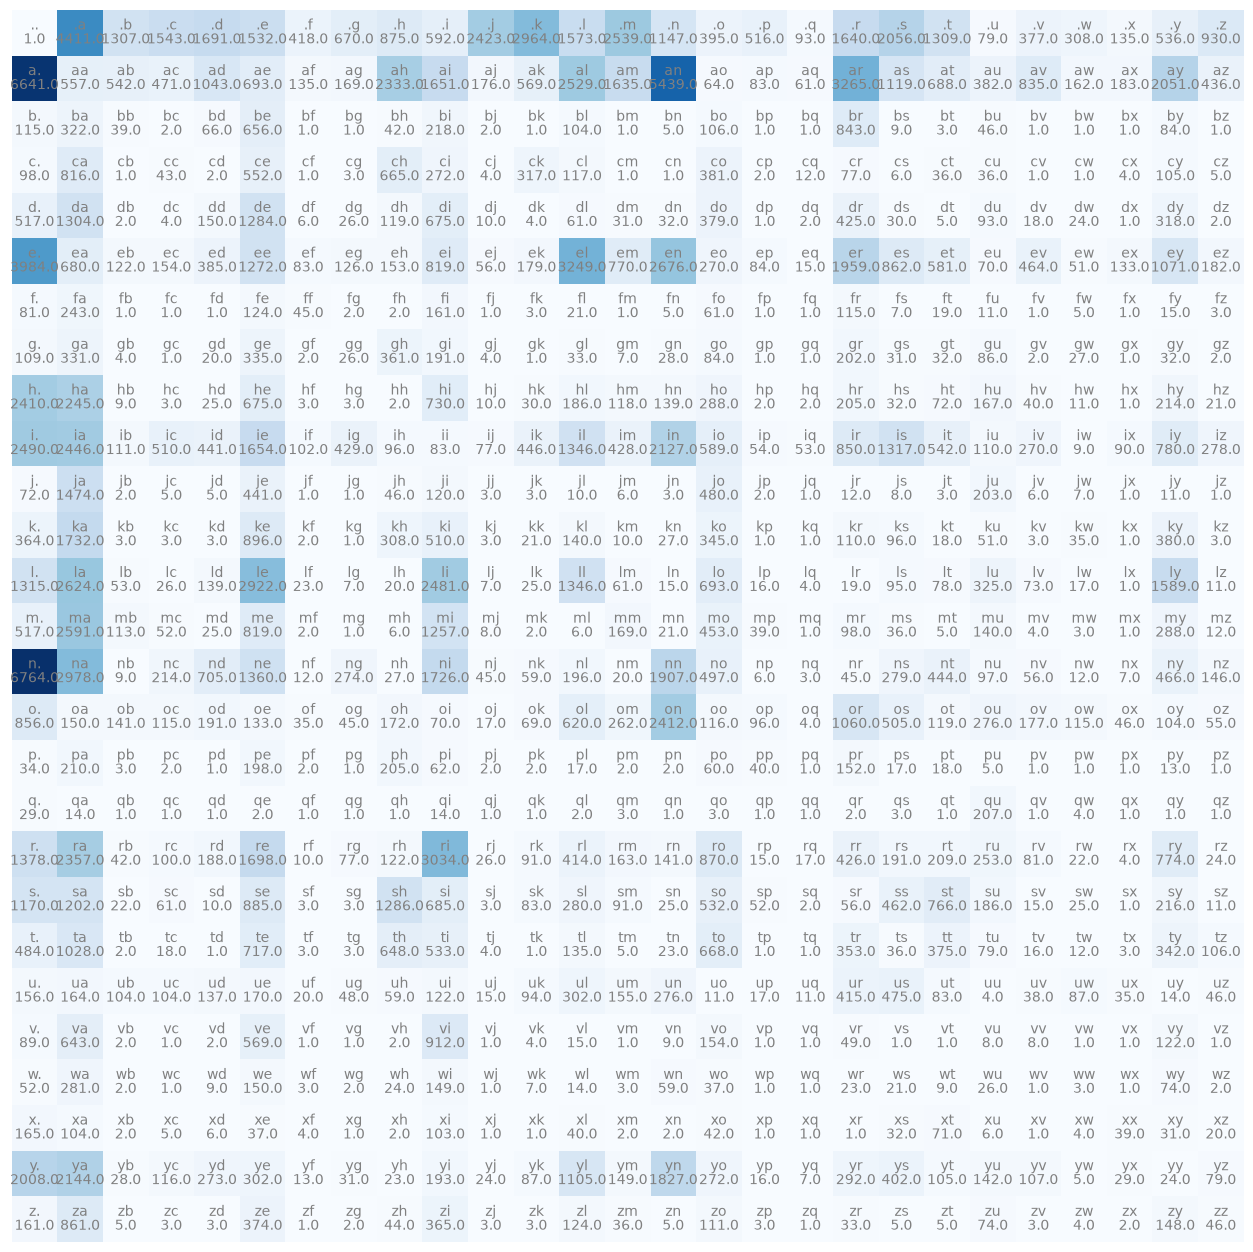

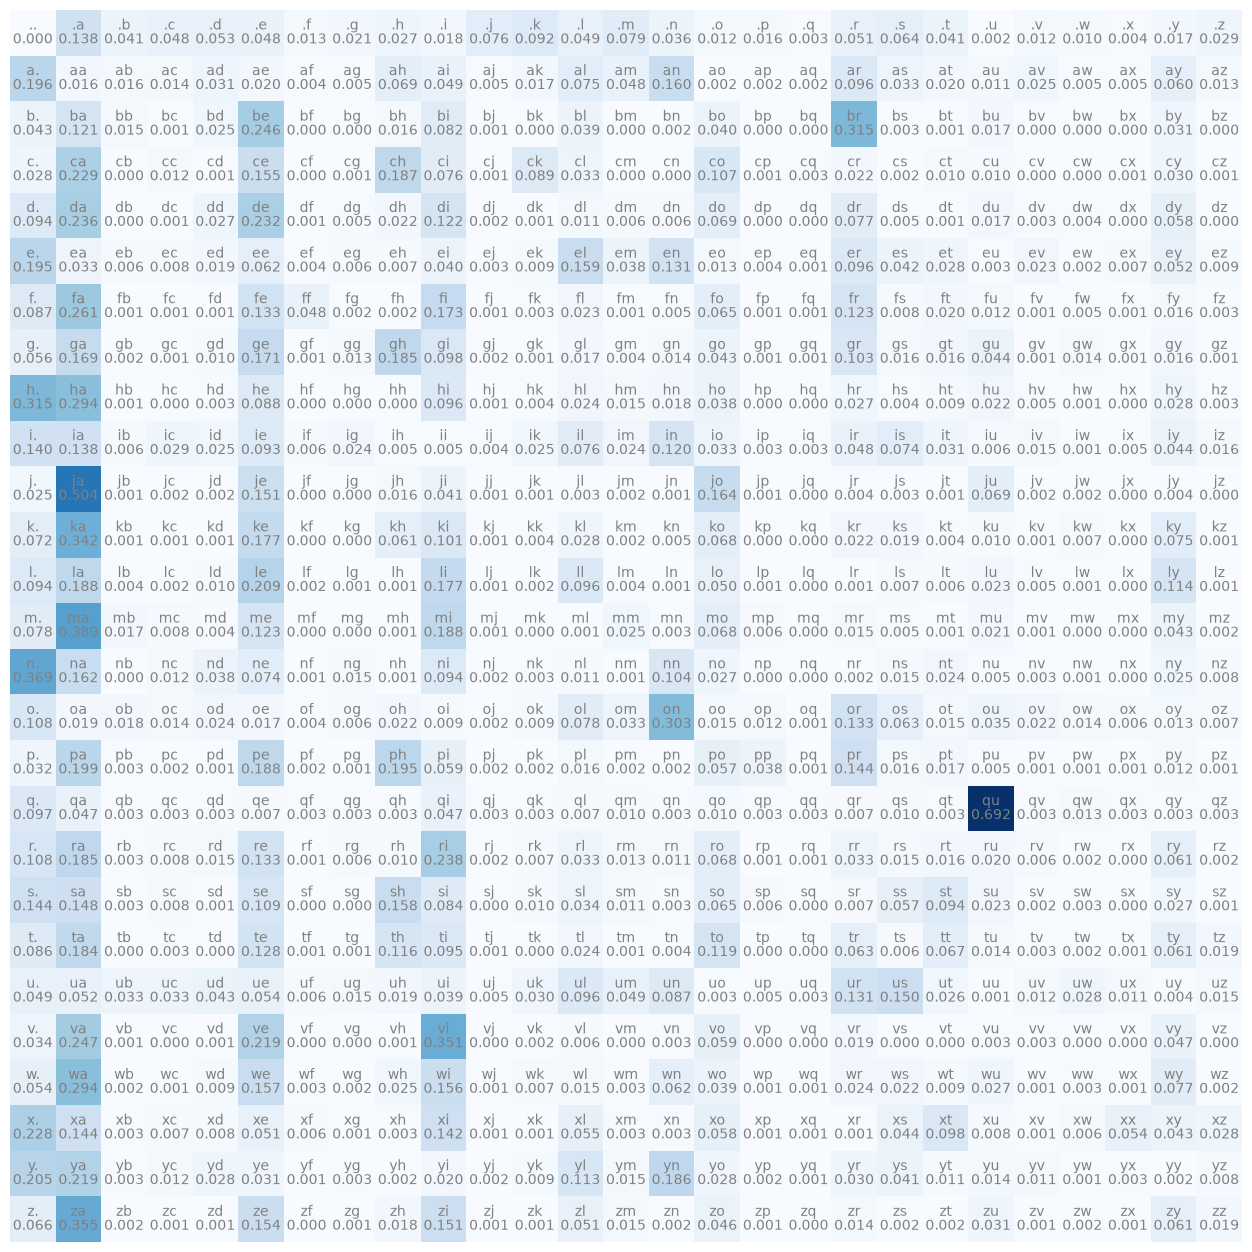

In [72]:
# Add 1 to every count (Laplace smoothing) so no bigram has probability zero, then normalize each row to sum to 1 -- turning the count matrix into a real conditional probability table P(next char | current char).
# The two heatmaps show the matrix before and after that normalization, to make the transformation visible.

# added padding for infinity error consideration

padding = 1
P=(N+padding).float()

print(P)

plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f'{P[i, j].item()}', ha="center", va="top", color='gray')
plt.axis('off')

# normalize each row
P=P/P.sum(1,keepdim=True)

# what if we normlized thecol instead of the rows?
# P=P/P.sum(0,keepdim=True)
#print(P.shape)
#print(P.sum(0,keepdim=True).shape)
#print(P.sum(1,keepdim=True).shape)

plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f'{P[i, j].item():.3f}', ha="center", va="top", color='gray')
plt.axis('off')

### Sample Names from the Model

In [73]:
# Generate 100 new names by repeatedly sampling from P, starting at '.' and stopping once '.' is sampled again, to see what the counting-based model actually produces.

g = torch.Generator().manual_seed(2147483647)

for i in range(100):
    # list to keep name
    out = []
    # want to start out by looking at prob dist of starting with .
    ix=0
    while True:
        #p = N[ix].float()
        #p = p/p.sum()
        p=P[ix]
        # constant distrubution
        # p=torch.ones(27)/27.0

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.
me.
vifahevara.
jala.
j.
gh.
cryalan.
rlaylmacondo.
pera.
yd.
en.
aienossin.
me.
jancla.
tiesel.
jedahzynaleroneritotturiron.
cri.
alkismeamere.
morad.
lieintamaamnnf.
miayuleonteadajeya.
renari.
x.
keika.
s.
ynn.
miudawa.
chahan.
jondelie.
kedariza.
lha.
denoni.
kar.
kavanista.
kesorrlilaa.
lelike.
ssh.
drl.
rcagalaicalasion.
avallciny.
boh.
en.
caikeladeradefwiea.
fes.
malolela.
liy.
elan.
jalinain.
rmayoadish.
con.
alomaruikeee.


## 5. Evaluating the Model — Negative Log-Likelihood

Average NLL over every bigram in the dataset is the model's loss: lower is better, 0 would mean the model assigns probability 1 to every observed bigram.

In [74]:
# Score the whole model: sum the log-probability the model assigns to every real bigram in the dataset, since a good model should assign high probability to bigrams that actually occur.
# Negating and averaging turns that into a loss (lower is better) in the units gradient-based optimization expects later.

# prediction on each bigram

log_likelihood=0
n=0

for w in words:
    # pad word with starting with ending char
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip (chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob = P[ix1,ix2]
        logprob=torch.log(prob)
        log_likelihood += logprob
        n+=1
        # print(f'{ch1}{ch2} : {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')

# more entropy-> more information
# funnily enough, we want to learn less stuff when calculating error functions!
 
nll = -log_likelihood
print(f'{nll=}')
# quality of the model normalized for n
print(f'{nll/n=}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
nll/n=tensor(2.4544)


In [75]:
# Compare against the naive baseline of a uniform distribution over 27 characters, as a reference point for what 'no information at all' looks like versus what the model actually achieves.

# If instead of varialbe pdf, we have constant pdf 
print(1/27)
# If the model is perfect, it should fit the training data
# perfectly, we should have see 1 on all predictions

0.037037037037037035


### Sanity Check — Predicting a Single Word

In [76]:
# Zoom into a single word to see per-bigram probabilities and losses individually, to build intuition for what's actually driving the aggregate loss number above.

# how well does the model predict jake?
log_likelihood=0
n=0

for w in ["jake"]:
    # pad word with starting with ending char
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip (chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob = P[ix1,ix2]
        logprob=torch.log(prob)
        log_likelihood += logprob
        n+=1
        print(f'{ch1}{ch2} : {prob:.4f} {logprob:.4f}')
        print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n=}')

# what a bad prediction!

.j : 0.0756 -2.5826
log_likelihood=tensor(-2.5826)
ja : 0.5036 -0.6860
log_likelihood=tensor(-3.2686)
ak : 0.0168 -4.0876
log_likelihood=tensor(-7.3562)
ke : 0.1768 -1.7326
log_likelihood=tensor(-9.0888)
e. : 0.1948 -1.6357
log_likelihood=tensor(-10.7245)
nll=tensor(10.7245)
nll/n=tensor(2.1449)


## 6. Neural Network Approach

Same bigram model, reframed as a single linear layer trained with gradient descent instead of counting.

### 6a. Build the Training Set
Every `(ch1, ch2)` bigram becomes one `(x, y)` training example.

In [77]:
# Convert one training word into paired (input char, target next-char) index lists -- the same shape of data the full model needs, kept tiny here so it's easy to inspect by hand.

# create the training set of bigrams (x,y)
xs, ys = [],[]


for w in words[:1]:
    # pad word with starting with ending char
    chs = ['.'] + list(w) + ['.']
    # 2 pointers for the first and second char of padded word
    #print(chs)
    for ch1, ch2 in zip (chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        print(ch1,ch2)
        xs.append(ix1)
        ys.append(ix2)
print(xs)
xs=torch.tensor(xs)
ys=torch.tensor(ys)


. e
e m
m m
m a
a .
[0, 5, 13, 13, 1]


In [78]:
# Look at the raw input indices to confirm they pair up with ys the way we expect.

# input
# since each char in leading bigram predicts what comes after
xs

tensor([ 0,  5, 13, 13,  1])

In [79]:
# Look at the target indices, and note we still need a way to turn a bare integer id into something a network can consume.

# prediction
ys

# we shall find a way to encode the symbols into inputs to NN

tensor([ 5, 13, 13,  1,  0])

### 6b. One-Hot Encode the Inputs
Each integer index becomes a length-27 one-hot vector so it can be matrix-multiplied against a weight matrix.

In [80]:
# One-hot encode the integer indices into 27-dim vectors, since a neural net needs numeric, differentiable input rather than a bare integer id.

import torch.nn.functional as F
xenc=F.one_hot(xs,num_classes=27).float()
yenc=F.one_hot(ys,num_classes=27).float()
xenc.shape

torch.Size([5, 27])

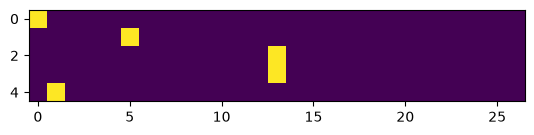

In [81]:
# Visualize the one-hot encoded inputs as an image, to confirm each row really is a single 1 in the correct column.

plt.imshow(xenc)

In [82]:
# Check the encoded inputs' dtype, since the matmul below requires it to match the weight matrix's dtype.

xenc.dtype

torch.float32

In [83]:
# Confirm the encoded inputs' shape (examples x vocab size) lines up with what the matmul below expects.

xenc.shape

torch.Size([5, 27])

### 6c. Linear Layer — Compute Logits
`xenc @ W` produces one row of 27 "log-count" scores per example. Raw scores can be negative, which is why the next step exponentiates them.

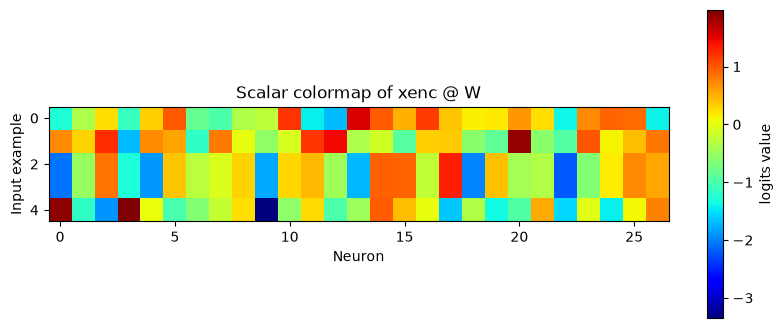

tensor([-1.2701, -0.3643,  0.2356, -1.1258,  0.3193,  0.9809, -0.8143, -0.9837,
        -0.3666, -0.2640,  1.1930, -1.4159, -1.6873,  1.5534,  0.9780,  0.4958,
         1.1517,  0.3791,  0.1428,  0.1814,  0.6297,  0.2422, -1.3921,  0.7118,
         0.9340,  0.8779, -1.3990])

In [84]:
# Introduce the actual 'neuron' weights as a random 27x27 matrix and compute logits via matmul -- the neural-net analogue of looking up a row in N.
# Visualizing the raw logits shows they can be negative, which is exactly why a normalization step (softmax) is needed next.

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

W = torch.randn((27, 27))
logits = xenc @ W # log counts

normalize = mcolors.Normalize(
    vmin=logits.min().item(),
    vmax=logits.max().item()
)
colormap = cm.jet

plt.figure(figsize=(10, 4))
plt.imshow(logits.detach().numpy(), cmap=colormap, norm=normalize)
plt.colorbar(label="logits value")
plt.xlabel("Neuron")
plt.ylabel("Input example")
plt.title("Scalar colormap of xenc @ W")
plt.show()

logits[0,:]
# issues, out network outputs negative logits values,
# bad for normalization, 

In [85]:
# Confirm the logits' output shape matches expectations: one 27-length score vector per example.

logits.shape

torch.Size([5, 27])

### 6d. Softmax — Convert Logits to Probabilities
Exponentiate (forces positivity) then row-normalize (forces each row to sum to 1) — the same row-normalization pattern as the counting-based model in section 4, now applied to `logits`.

In [86]:
# Turn raw logits into a valid probability distribution the same way section 4 turned counts into probabilities: exponentiate to force positivity, then row-normalize to force each row to sum to 1 -- this is exactly softmax.

# Softmaxing
# (5 x 27) (/element wise div) (5 * 27) = (5 x 27) / (5 x 1)
# w_i / w_sum = e^w_i / e^w_sum

# Convert each logits to e^logits
counts = torch.exp(logits)

# Divide every row by its row sum
# dim = 1 compress counts on dim 1 (5x27)->(5x1)
# then (5x27)/(5x1) = (5x27)/(5x27) col broadcasts
prob = counts / counts.sum(1,keepdim=True)
prob.sum(1,keepdim=True)

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

## 7. Training Harness — End-to-End Pipeline

In [87]:
# Set up the network for training from scratch: fix a seed for reproducibility and randomly initialize one 27x27 weight matrix (one row of 27 weights per possible input character).

print(xs)
print(ys)

# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [88]:
# Run one forward pass end-to-end (encode -> logits -> softmax) to see the model's predictions before any training has happened.

xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [89]:
# Sanity-check the softmax output's shape.

probs.shape

torch.Size([5, 27])

In [90]:
# Walk through the loss computation bigram-by-bigram for the first 5 examples, printing every intermediate value, to make concrete what the aggregate loss actually represents at the individual-example level.

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

### Optimizaiton

In [91]:
# Re-initialize the weights, this time with requires_grad=True, since we're about to compute gradients and update W via backprop instead of just inspecting a fixed random forward pass.

print(xs)
print(ys)

# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
# to backprop on W need to enable requires grad
W = torch.randn((27, 27), generator=g,requires_grad=True)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [92]:
# Recompute the one-hot encoding as step 1 of what becomes the training loop's forward pass.

xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding

In [93]:
# Compute logits, softmax probabilities, and the average negative log-likelihood loss as a manual single-step walkthrough, before wrapping this into a repeatable training loop.

logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()

In [94]:
# Print the current scalar loss to see the starting point before calling backward().

print(loss.item())

3.7693049907684326


In [95]:
# Compute gradients of the loss w.r.t. every weight in W via backprop, after resetting any old gradient to None first (PyTorch accumulates gradients by default, so this reset matters every step).

# backward pass
W.grad = None # set to zero the gradient
loss.backward(retain_graph=True)

In [96]:
# Inspect the actual gradient values, to see which direction and how strongly each weight should move to reduce the loss.

W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [97]:
# Confirm W's shape once more before applying the update below.

W.shape

torch.Size([27, 27])

In [98]:
# Manually apply one gradient descent step: nudge every weight in the direction that decreases the loss, scaled by a learning rate of 0.1 -- the update rule that gets wrapped into a loop next.

W.data += -0.1 * W.grad

In [99]:
# Scale up from the single-word toy example to the full dataset, and re-initialize a fresh W so training starts from a clean random state rather than wherever cell 61 already nudged it.

# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [ ]:
# Repeat forward -> loss -> backward -> update automatically for many steps so the weights actually converge, instead of taking one manual step at a time.
# The added L2 term (0.01*(W**2).mean()) discourages extreme weights, playing the same role Laplace smoothing played for the counting-based model.

# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # training input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts

  # soft max
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

  # log loss
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  #print(loss.item())

  # realisticly we use
  # F.cross_entropy(logits,Y)


  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward(retain_graph=True)
  
  # update
  # try adjusting step
  step = 25
  W.data += -step * W.grad

print(loss.item())

2.480402708053589


In [159]:
# Generate names from the trained network the same way cell 28 sampled from P, but computing each probability row on the fly via a forward pass instead of a precomputed table -- letting us compare the two approaches' output directly.

# finally, sample from the 'neural net' model
#g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

j.
gh.
cryalan.
rlrylmach.
ro.


In [102]:
# Confirm the first row of probabilities really does sum to 1, verifying the softmax normalization worked.

probs[0,:].sum()

tensor(1., grad_fn=<SumBackward0>)